In [1]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import simulations.genomes1000_sim as sim_functions

intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'

In [3]:
# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.5,1]
num_markers_assoc_list = [100,2000]
init_list = range(100) # 100 random initializations for each combination
bfile_path=f'{output_dir}/G'
af_df_filepath=admixture_filepath
# PARAMETERS

## Explore 1000 genomes data

### Run GWAS with and without PCs and see how much genetic coefficients change 

Code to run SAIGE and PLINK gwas

make graph of GWAS

In [108]:
ps=True
e=0.5 
init=0 
num_markers_assoc=100 
phenotypic_subgroup=2
print(f'running for phenotypic subgroup {phenotypic_subgroup}',flush=True)
output_file_suffix = sim_functions.get_output_file_suffix(ps, e, init, num_markers_assoc)
meta_path = f"{output_dir}/simulation_metadata_{output_file_suffix}.pkl"
with open(meta_path, "rb") as f:
    simulation_metadata = pickle.load(f)
associated_markers = set(simulation_metadata["markers_assoc"][phenotypic_subgroup]) if phenotypic_subgroup in range(2) else set()

# read parquet with all gwas info
df = pd.read_parquet(f"{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}.parquet")    

# get confusion matrix
df = df.assign(is_assoc = df["ID"].isin(associated_markers),is_sig   = df["P"] < 5e-8)
conf_by_method = (
    df.groupby("assoc_test",group_keys=False)
    .apply(lambda g: pd.Series({
        "tp": ( g["is_sig"]  &  g["is_assoc"]).sum(),
        "fp": ( g["is_sig"]  & ~g["is_assoc"]).sum(),
        "tn": (~g["is_sig"]  & ~g["is_assoc"]).sum(),
        "fn": (~g["is_sig"]  &  g["is_assoc"]).sum(),})).reset_index())
conf_by_method = conf_by_method.assign(
accuracy  = lambda d: (d.tp + d.tn) / (d.tp + d.fp + d.tn + d.fn),
precision = lambda d: d.tp / np.where((d.tp + d.fp) == 0, np.nan, d.tp + d.fp),
recall    = lambda d: d.tp / np.where((d.tp + d.fn) == 0, np.nan, d.tp + d.fn),
specificity = lambda d: d.tn / np.where((d.tn + d.fp) == 0, np.nan, d.tn + d.fp),
f1        = lambda d: (2*d.tp) / np.where((2*d.tp + d.fp + d.fn) == 0, np.nan, 2*d.tp + d.fp + d.fn))

# get change in beta and average abs beta
results_df = df.groupby('assoc_test',group_keys=False)['BETA'].apply(lambda x: x.abs().mean()).reset_index(name="avg_abs_beta")
results_df = (results_df.merge(df[df["ID"].isin(associated_markers)].groupby('assoc_test',group_keys=False)['BETA'].apply(lambda x: x.abs().mean())
                                .reset_index(name="avg_abs_beta_assoc"),on='assoc_test',how='left'))
wide = df.pivot(index="ID", columns="assoc_test", values="BETA")
y_true = wide.index.isin(associated_markers)# get those that are truly assoc.
wide["rel_change_LR_W_COVS"] = (wide["LR w/ Covs"].abs() - wide["LR"].abs()) / wide["LR"].abs()
wide["rel_change_SAIGE_W_COVS"] = (wide["SAIGE w/ Covs"].abs() - wide["LR"].abs()) / wide["LR"].abs()
wide["rel_change_LR_W_COVS_assoc"] = (wide.loc[y_true]["LR w/ Covs"].abs() - wide.loc[y_true]["LR"].abs()) / wide.loc[y_true]["LR"].abs()
wide["rel_change_SAIGE_W_COVS_assoc"] = (wide.loc[y_true]["SAIGE w/ Covs"].abs() - wide.loc[y_true]["LR"].abs()) / wide.loc[y_true]["LR"].abs()
prop_changes = {
    "LR": {'prop_rel_change_gt10':0.0, 'prop_rel_change_gt10_associated':0.0},
    "LR w/ Covs": {'prop_rel_change_gt10':(wide["rel_change_LR_W_COVS"] > 0.10).mean(), 
                'prop_rel_change_gt10_associated':(wide.loc[wide["rel_change_LR_W_COVS_assoc"].notna(),"rel_change_LR_W_COVS_assoc"] > 0.10).mean()},
    "SAIGE w/ Covs": {'prop_rel_change_gt10':(wide["rel_change_SAIGE_W_COVS"] > 0.10).mean(), 
                    'prop_rel_change_gt10_associated':(wide.loc[wide["rel_change_SAIGE_W_COVS_assoc"].notna(),"rel_change_SAIGE_W_COVS_assoc"] > 0.10).mean()}
}
prop_df = pd.DataFrame.from_dict(prop_changes, orient="index").reset_index(names='assoc_test')
results_df = results_df.merge(prop_df,on='assoc_test')
results_df = results_df.merge(conf_by_method,on='assoc_test')

# set param values
results_df['ps'] = ps
results_df['e'] = e
results_df['init'] = init
results_df['num_markers_assoc'] = num_markers_assoc
print(f'recording phenotypic subgroup as {phenotypic_subgroup}')
results_df['phenotypic_subgroup'] = phenotypic_subgroup

running for phenotypic subgroup 2
recording phenotypic subgroup as 2


In [ ]:
from itertools import product
import os, pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from pyarrow.lib import ArrowInvalid


SIG = 5e-8
results_df = []


def evaluate_gwas(output_dir,ps, e, init, num_markers_assoc, phenotypic_subgroup,sig_level=5e-8):
    output_file_suffix = sim_functions.get_output_file_suffix(ps, e, init, num_markers_assoc)
    meta_path = f"{output_dir}/simulation_metadata_{output_file_suffix}.pkl"
    with open(meta_path, "rb") as f:
        simulation_metadata = pickle.load(f)
    associated_markers = set(simulation_metadata["markers_assoc"][phenotypic_subgroup]) if phenotypic_subgroup in range(2) else set()

    # read parquet with all gwas info
    df = pd.read_parquet(f"{output_dir}/GWAS_RESULTS/PhenotypicSubgroup{phenotypic_subgroup}_{output_file_suffix}.parquet")    
   
    # get confusion matrix
    df = df.assign(is_assoc = df["ID"].isin(associated_markers),is_sig   = df["P"] < sig_level)
    conf_by_method = (
        df.groupby("assoc_test",group_keys=False)
        .apply(lambda g: pd.Series({
            "tp": ( g["is_sig"]  &  g["is_assoc"]).sum(),
            "fp": ( g["is_sig"]  & ~g["is_assoc"]).sum(),
            "tn": (~g["is_sig"]  & ~g["is_assoc"]).sum(),
            "fn": (~g["is_sig"]  &  g["is_assoc"]).sum(),})).reset_index())
    conf_by_method = conf_by_method.assign(
    accuracy  = lambda d: (d.tp + d.tn) / (d.tp + d.fp + d.tn + d.fn),
    precision = lambda d: d.tp / np.where((d.tp + d.fp) == 0, np.nan, d.tp + d.fp),
    recall    = lambda d: d.tp / np.where((d.tp + d.fn) == 0, np.nan, d.tp + d.fn),
    specificity = lambda d: d.tn / np.where((d.tn + d.fp) == 0, np.nan, d.tn + d.fp),
    f1        = lambda d: (2*d.tp) / np.where((2*d.tp + d.fp + d.fn) == 0, np.nan, 2*d.tp + d.fp + d.fn))

    # get change in beta and average abs beta
    results_df = df.groupby('assoc_test',group_keys=False)['BETA'].apply(lambda x: x.abs().mean()).reset_index(name="avg_abs_beta")
    results_df = (results_df.merge(df[df["ID"].isin(associated_markers)].groupby('assoc_test',group_keys=False)['BETA'].apply(lambda x: x.abs().mean())
                                   .reset_index(name="avg_abs_beta_assoc"),on='assoc_test',how='left'))
    wide = df.pivot(index="ID", columns="assoc_test", values="BETA")
    y_true = wide.index.isin(associated_markers)# get those that are truly assoc.
    wide["rel_change_LR_W_COVS"] = ((wide["LR w/ Covs"] - wide["LR"]) / wide["LR"]).abs()
    wide["rel_change_SAIGE_W_COVS"] = ((wide["SAIGE w/ Covs"] - wide["LR"]) / wide["LR"]).abs()
    wide["rel_change_LR_W_COVS_assoc"] = ((wide.loc[y_true]["LR w/ Covs"] - wide.loc[y_true]["LR"]) / wide.loc[y_true]["LR"]).abs()
    wide["rel_change_SAIGE_W_COVS_assoc"] = ((wide.loc[y_true]["SAIGE w/ Covs"] - wide.loc[y_true]["LR"]) / wide.loc[y_true]["LR"]).abs()
    prop_changes = {
        "LR": {'prop_rel_change_gt10':0.0, 'prop_rel_change_gt10_associated':0.0},
        "LR w/ Covs": {'prop_rel_change_gt10':(wide["rel_change_LR_W_COVS"] > 0.10).mean(), 
                    'prop_rel_change_gt10_associated':(wide.loc[wide["rel_change_LR_W_COVS_assoc"].notna(),"rel_change_LR_W_COVS_assoc"] > 0.10).mean()},
        "SAIGE w/ Covs": {'prop_rel_change_gt10':(wide["rel_change_SAIGE_W_COVS"] > 0.10).mean(), 
                        'prop_rel_change_gt10_associated':(wide.loc[wide["rel_change_SAIGE_W_COVS_assoc"].notna(),"rel_change_SAIGE_W_COVS_assoc"] > 0.10).mean()}
    }
    prop_df = pd.DataFrame.from_dict(prop_changes, orient="index").reset_index(names='assoc_test')
    results_df = results_df.merge(prop_df,on='assoc_test')
    results_df = results_df.merge(conf_by_method,on='assoc_test')

    # set param values
    results_df['ps'] = ps
    results_df['e'] = e
    results_df['init'] = init
    results_df['num_markers_assoc'] = num_markers_assoc
    results_df['phenotypic_subgroup'] = phenotypic_subgroup

    return results_df


In [130]:
from itertools import product
from joblib import Parallel, delayed
import pandas as pd

combos = list(product(ps_list, [0.50,1], init_list, num_markers_assoc_list, range(4)))
results_df_indiv = Parallel(n_jobs=-1)(
    delayed(evaluate_gwas)(
        output_dir=output_dir,
        ps=ps, e=e, init=init, num_markers_assoc=num_markers_assoc, 
        phenotypic_subgroup=phenotypic_subgroup, sig_level=5e-8
    )
    for (ps, e, init, num_markers_assoc, phenotypic_subgroup) in combos
)

results_df = pd.concat(results_df_indiv)
results_df

,assoc_test,avg_abs_beta,avg_abs_beta_assoc,prop_rel_change_gt10,prop_rel_change_gt10_associated,tp,fp,tn,fn,accuracy,precision,recall,specificity,f1,ps,e,init,num_markers_assoc,phenotypic_subgroup
0,LR,0.399090,0.519126,0.0000,0.00,59,2985,6915,41,0.6974,0.019382,0.59,0.698485,0.037532,True,0.5,0,100,0
1,LR w/ Covs,0.093187,0.240788,0.9844,0.99,0,0,9900,100,0.9900,NaN,0.00,1.000000,0.000000,True,0.5,0,100,0
2,SAIGE w/ Covs,0.093366,0.240932,0.9846,0.99,0,0,9900,100,0.9900,NaN,0.00,1.000000,0.000000,True,0.5,0,100,0
0,LR,0.454682,0.556748,0.0000,0.00,64,4051,5849,36,0.5913,0.015553,0.64,0.590808,0.030368,True,0.5,0,100,1
1,LR w/ Covs,0.088036,0.227425,0.9886,1.00,0,0,9900,100,0.9900,NaN,0.00,1.000000,0.000000,True,0.5,0,100,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,LR w/ Covs,0.121468,NaN,0.8818,NaN,0,0,10000,0,1.0000,NaN,NaN,1.000000,NaN,False,1.0,99,2000,2
2,SAIGE w/ Covs,0.120413,NaN,0.8847,NaN,0,0,10000,0,1.0000,NaN,NaN,1.000000,NaN,False,1.0,99,2000,2
0,LR,0.119053,NaN,0.0000,0.00,0,0,10000,0,1.0000,NaN,NaN,1.000000,NaN,False,1.0,99,2000,3
1,LR w/ Covs,0.122109,NaN,0.8743,NaN,0,0,10000,0,1.0000,NaN,NaN,1.000000,NaN,False,1.0,99,2000,3


In [117]:
results_df.to_csv(f'{output_dir}/results_df.csv')

Overall graphs

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 3200 rows containing non-finite values.


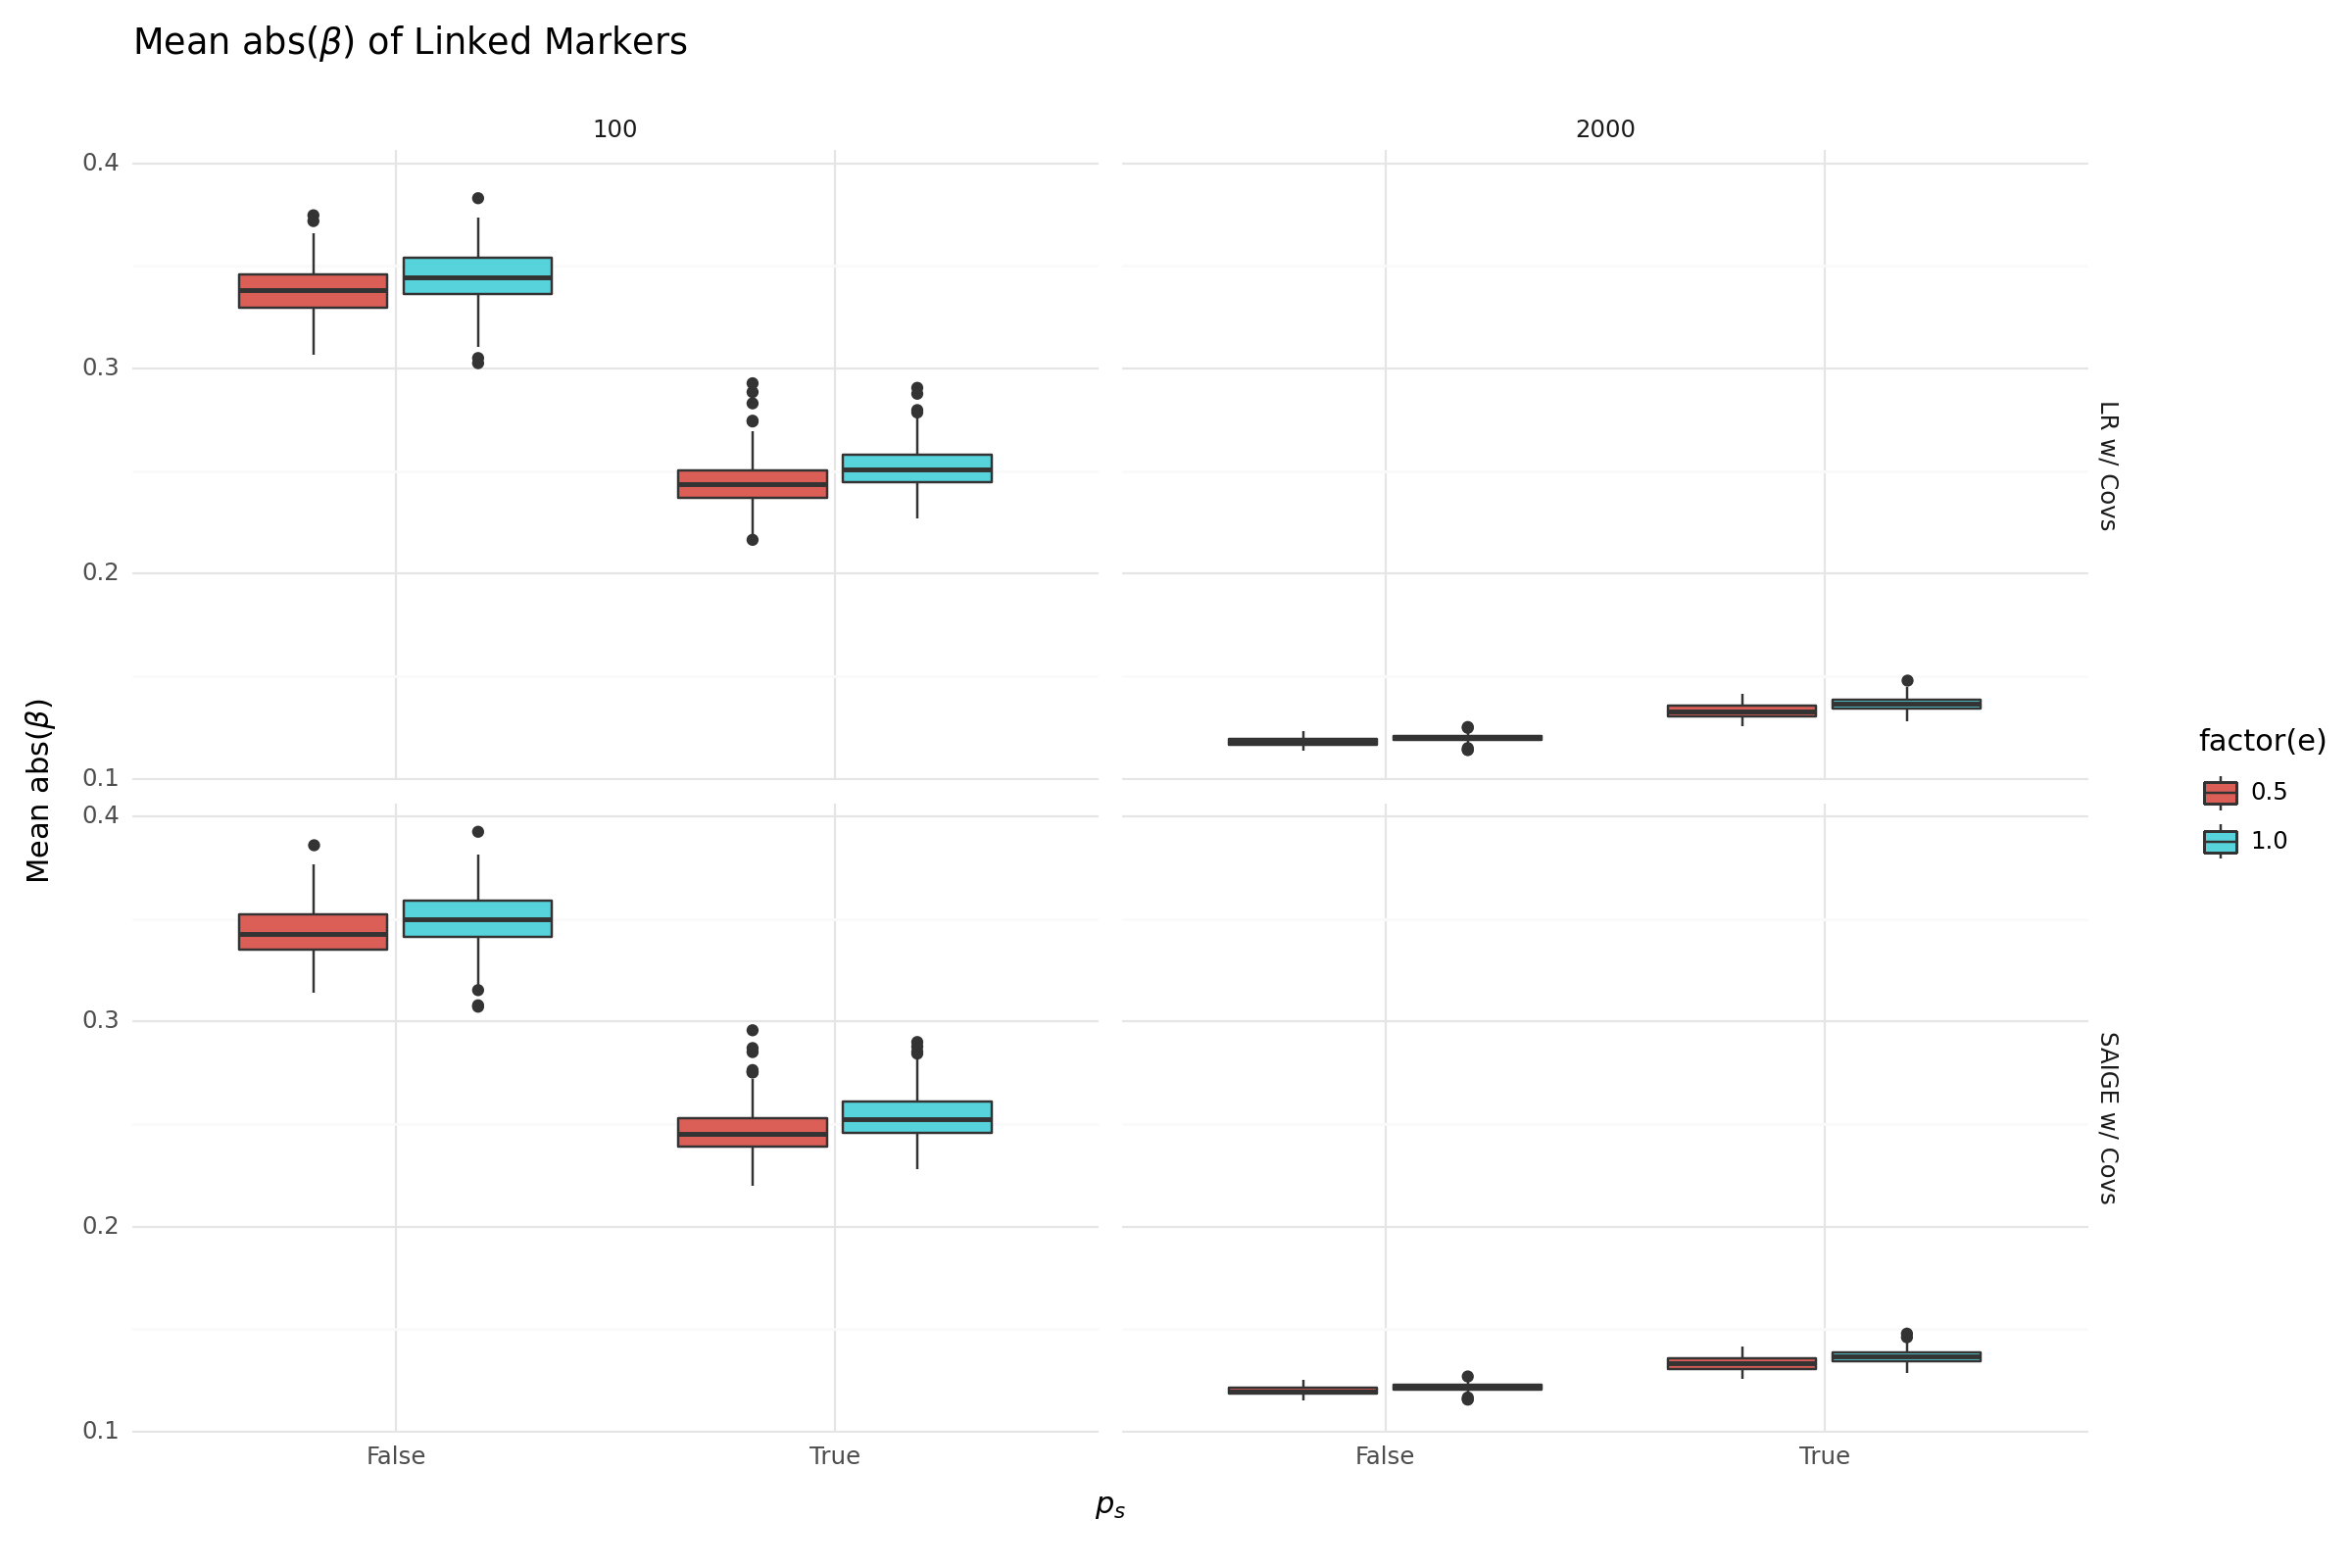

In [119]:
p = (ggplot(results_df[results_df['assoc_test']!='LR'], aes(x='ps', y='avg_abs_beta_assoc',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,8))
    + facet_grid('assoc_test ~ num_markers_assoc')
    + labs(title=r'Mean abs($\beta$) of Linked Markers',y=r'Mean abs($\beta$)',x=r'$p_s$')) 
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 1600 rows containing non-finite values.


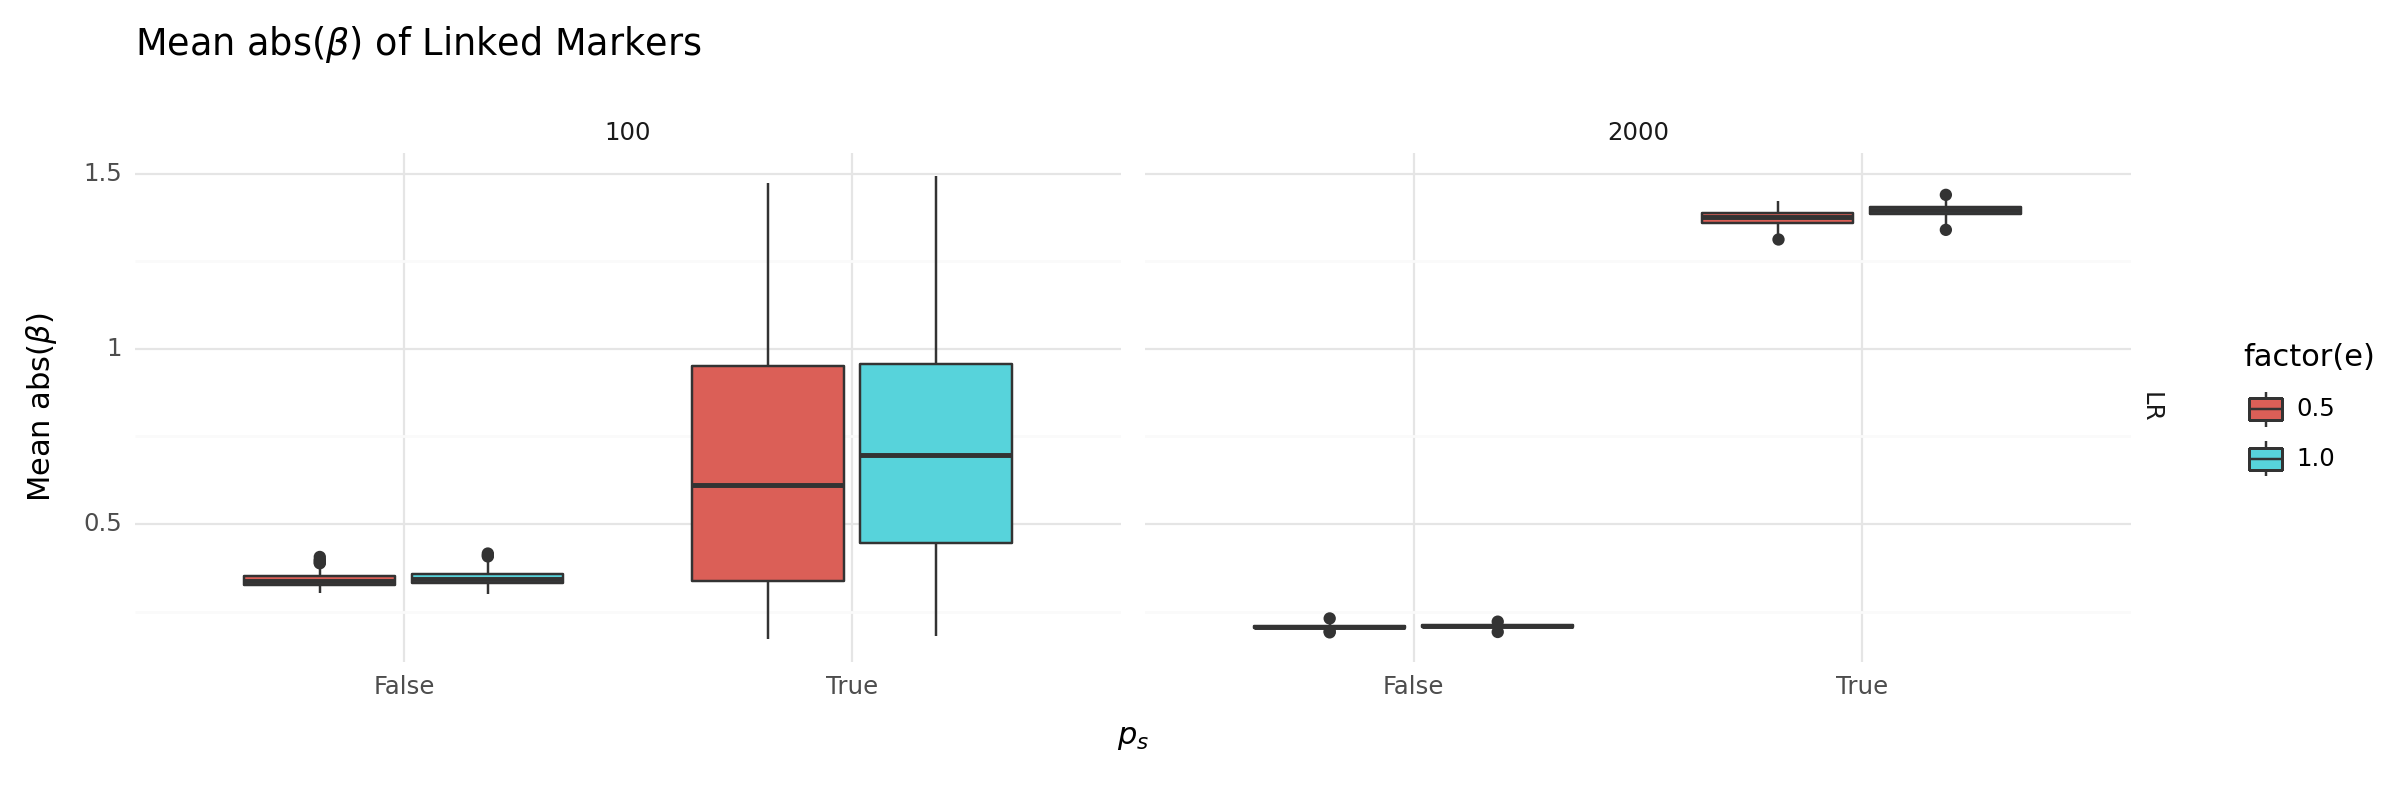

In [120]:
p = (ggplot(results_df[results_df['assoc_test']=='LR'], aes(x='ps', y='avg_abs_beta_assoc',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,4))
    + facet_grid('assoc_test ~ num_markers_assoc')
    + labs(title=r'Mean abs($\beta$) of Linked Markers',y=r'Mean abs($\beta$)',x=r'$p_s$')) 
print(p)

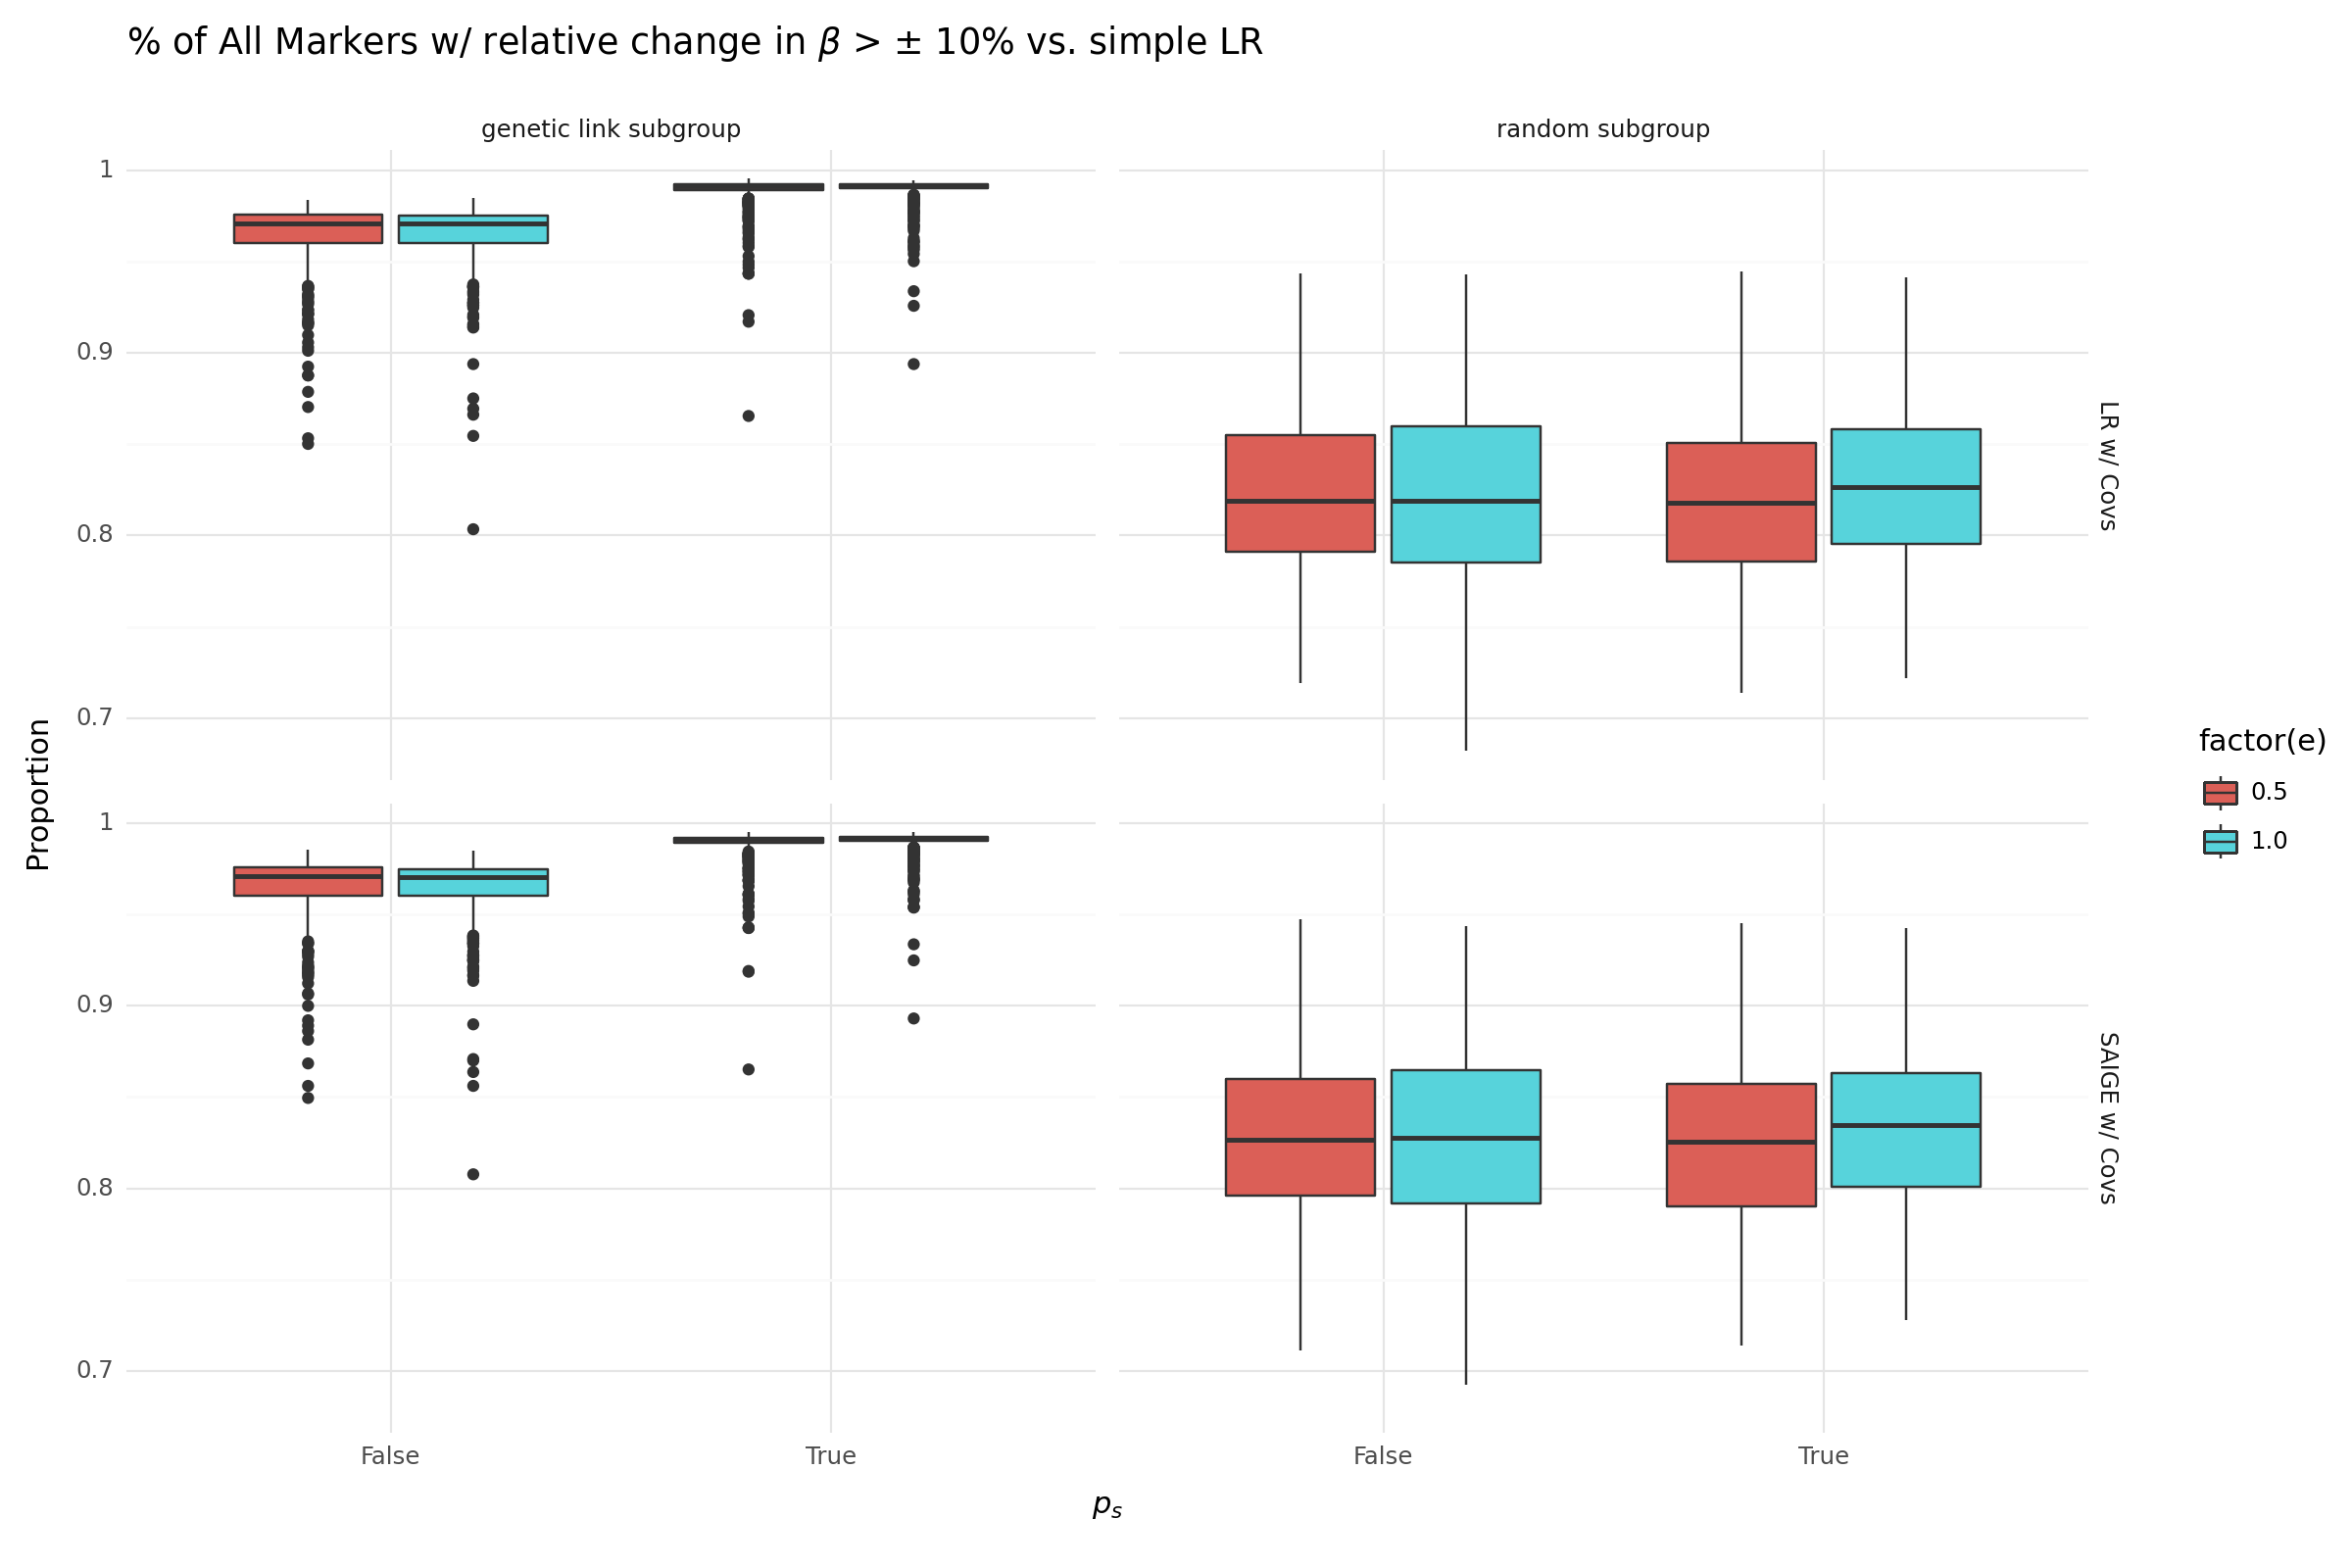

In [131]:
results_df['subgroup_type'] = results_df['phenotypic_subgroup'].apply(lambda x: 'genetic link subgroup' if x in range(2) else 'random subgroup')
p = (ggplot(results_df[results_df['assoc_test']!='LR'], aes(x='ps', y='prop_rel_change_gt10',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(12,8))
    + facet_grid('assoc_test ~ subgroup_type')
    + labs(title=r'% of All Markers w/ relative change in $\beta$ > $ \pm $ 10% vs. simple LR',y=r'Proportion',x=r'$p_s$')) 
print(p)

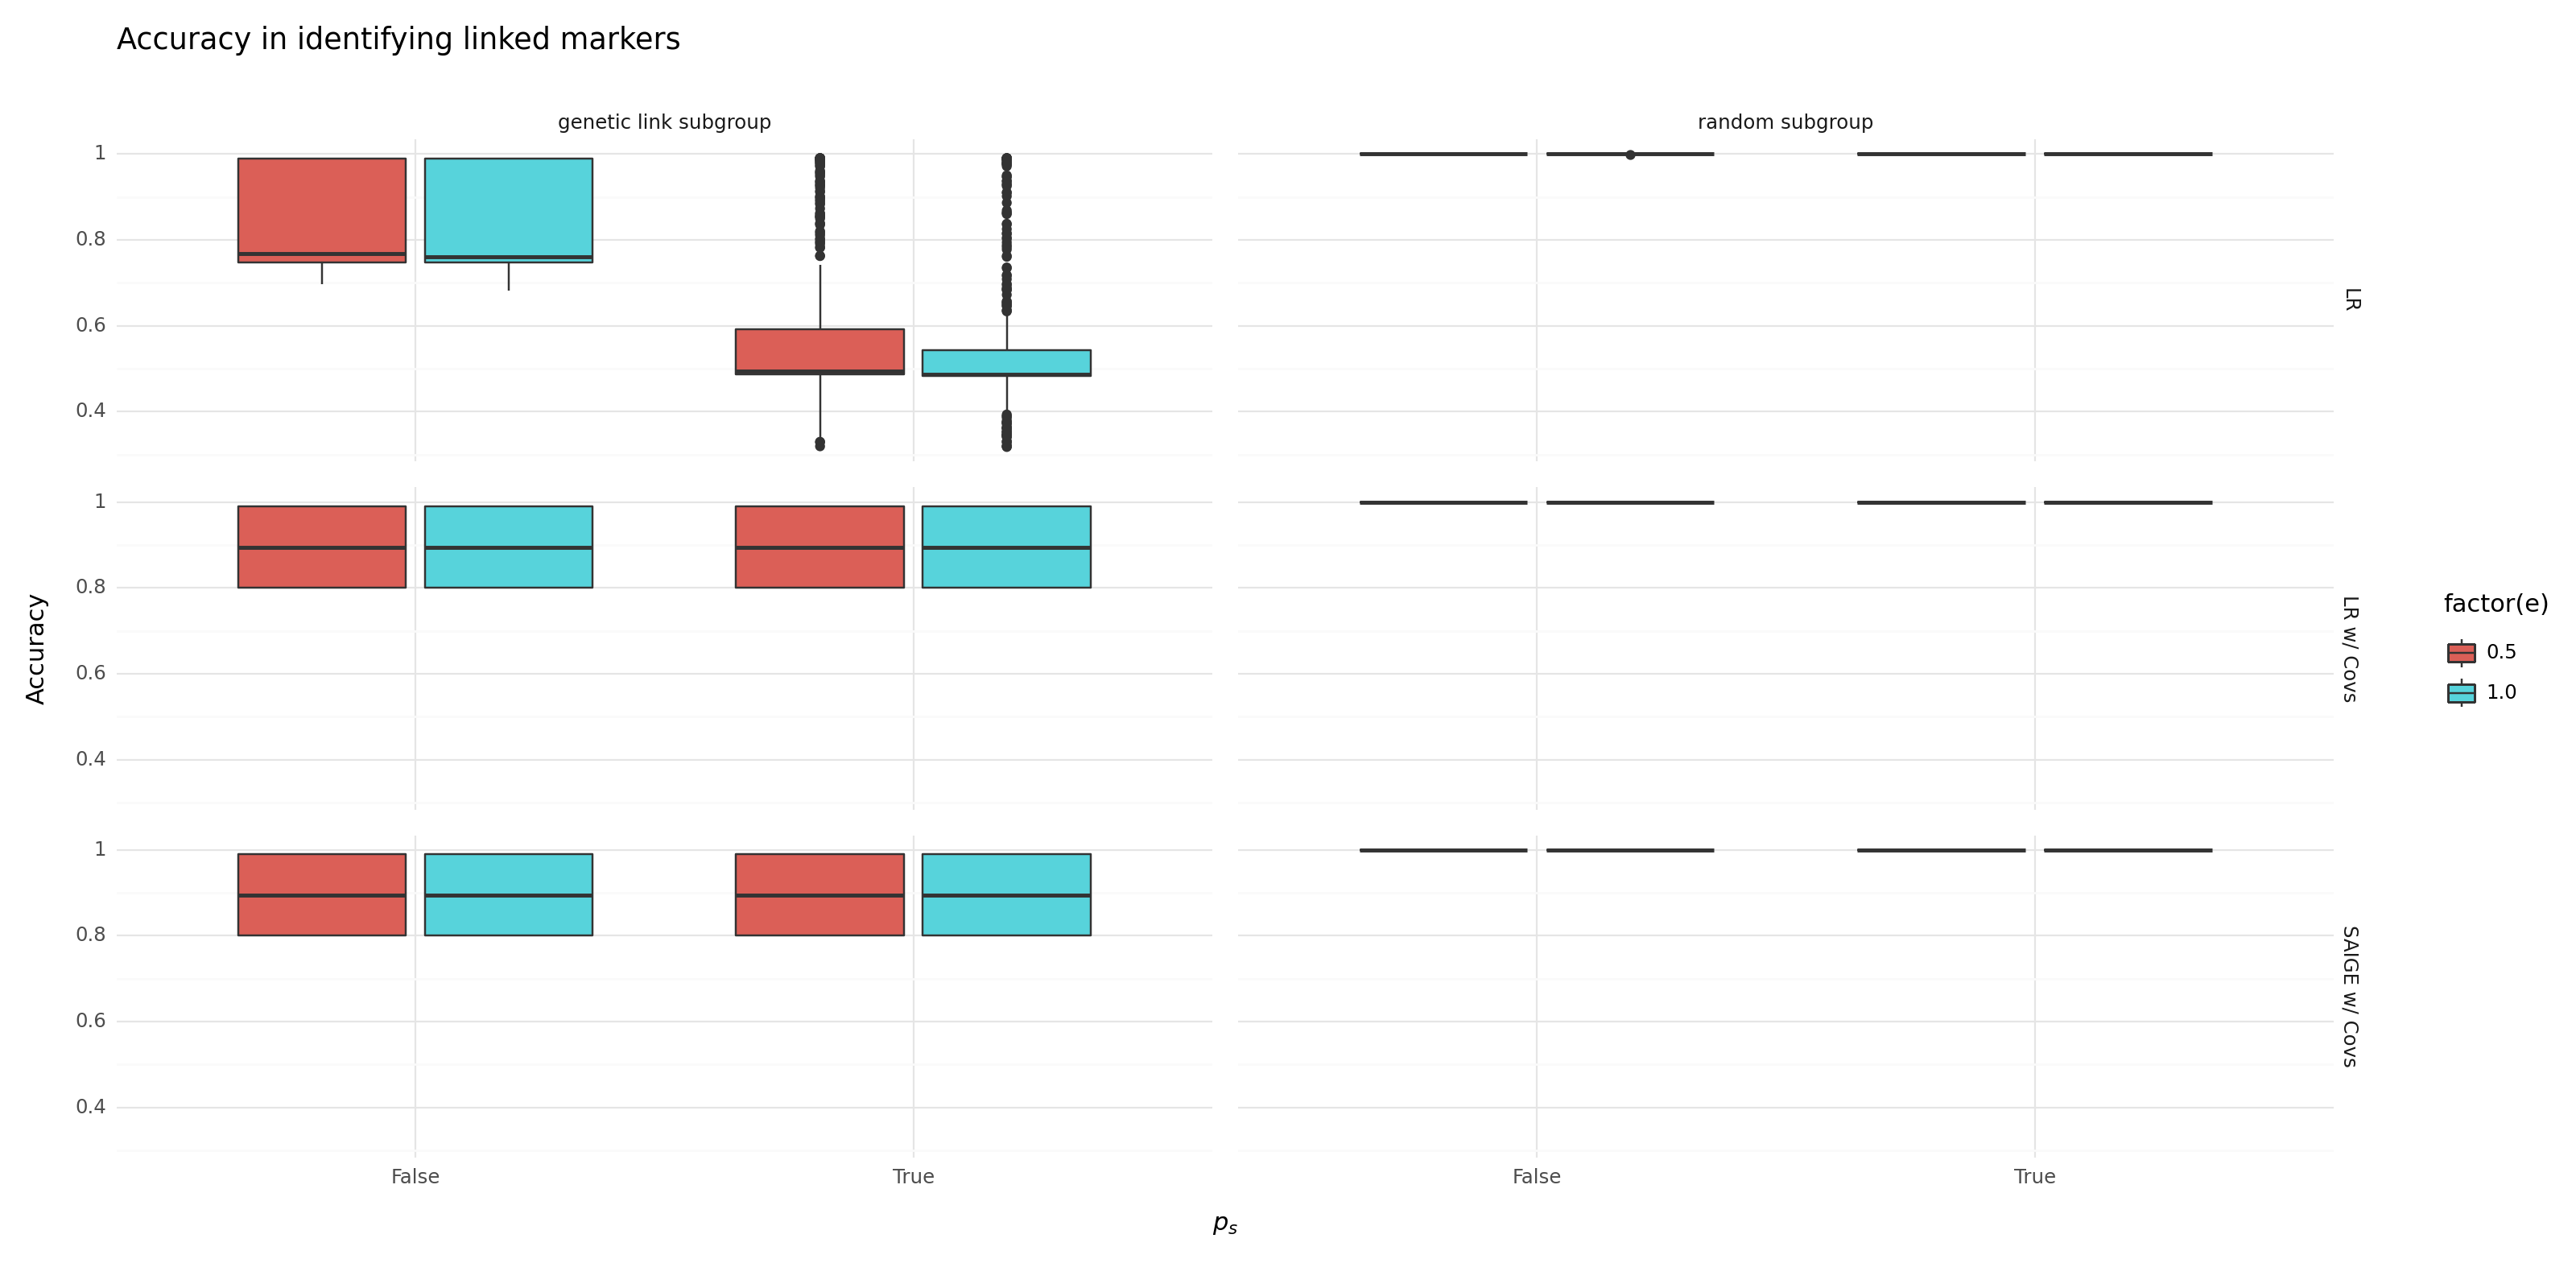

In [135]:
p = (ggplot(results_df, aes(x='ps', y='accuracy',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(16,8))
    + facet_grid('assoc_test ~ subgroup_type')
    + labs(title=r'Accuracy in identifying linked markers',y=r'Accuracy',x=r'$p_s$')) 
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 4800 rows containing non-finite values.


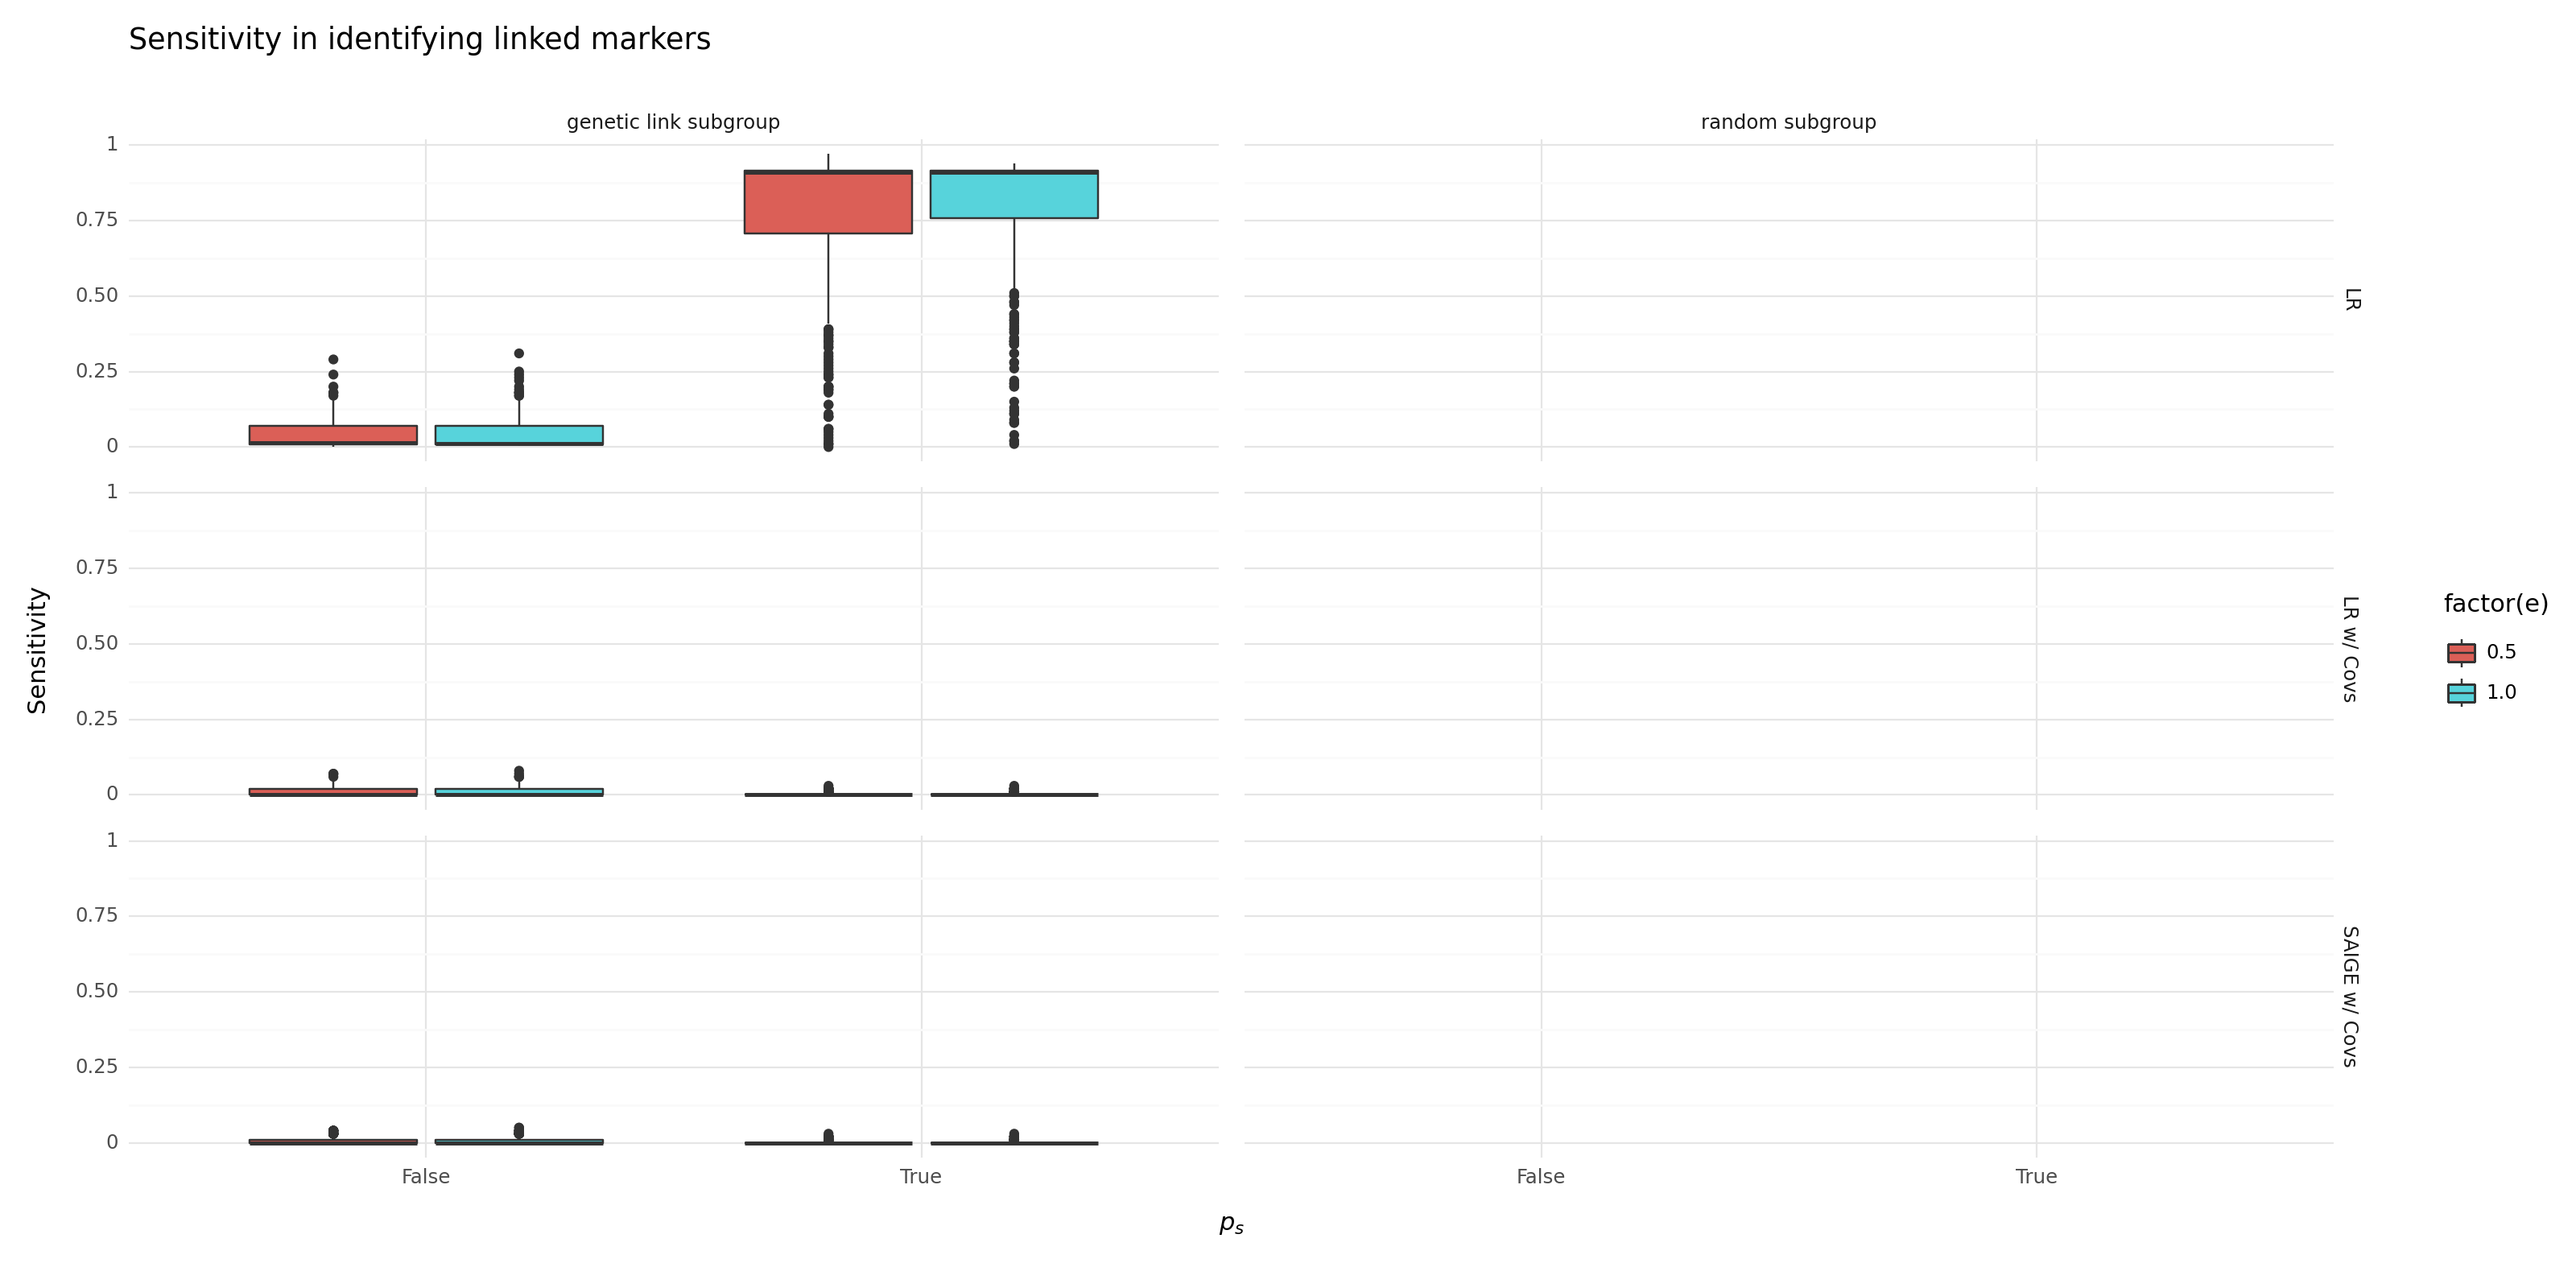

In [137]:
p = (ggplot(results_df, aes(x='ps', y='recall',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(16,8))
    + facet_grid('assoc_test ~ subgroup_type')
    + labs(title=r'Sensitivity in identifying linked markers',y=r'Sensitivity',x=r'$p_s$')) 
print(p)

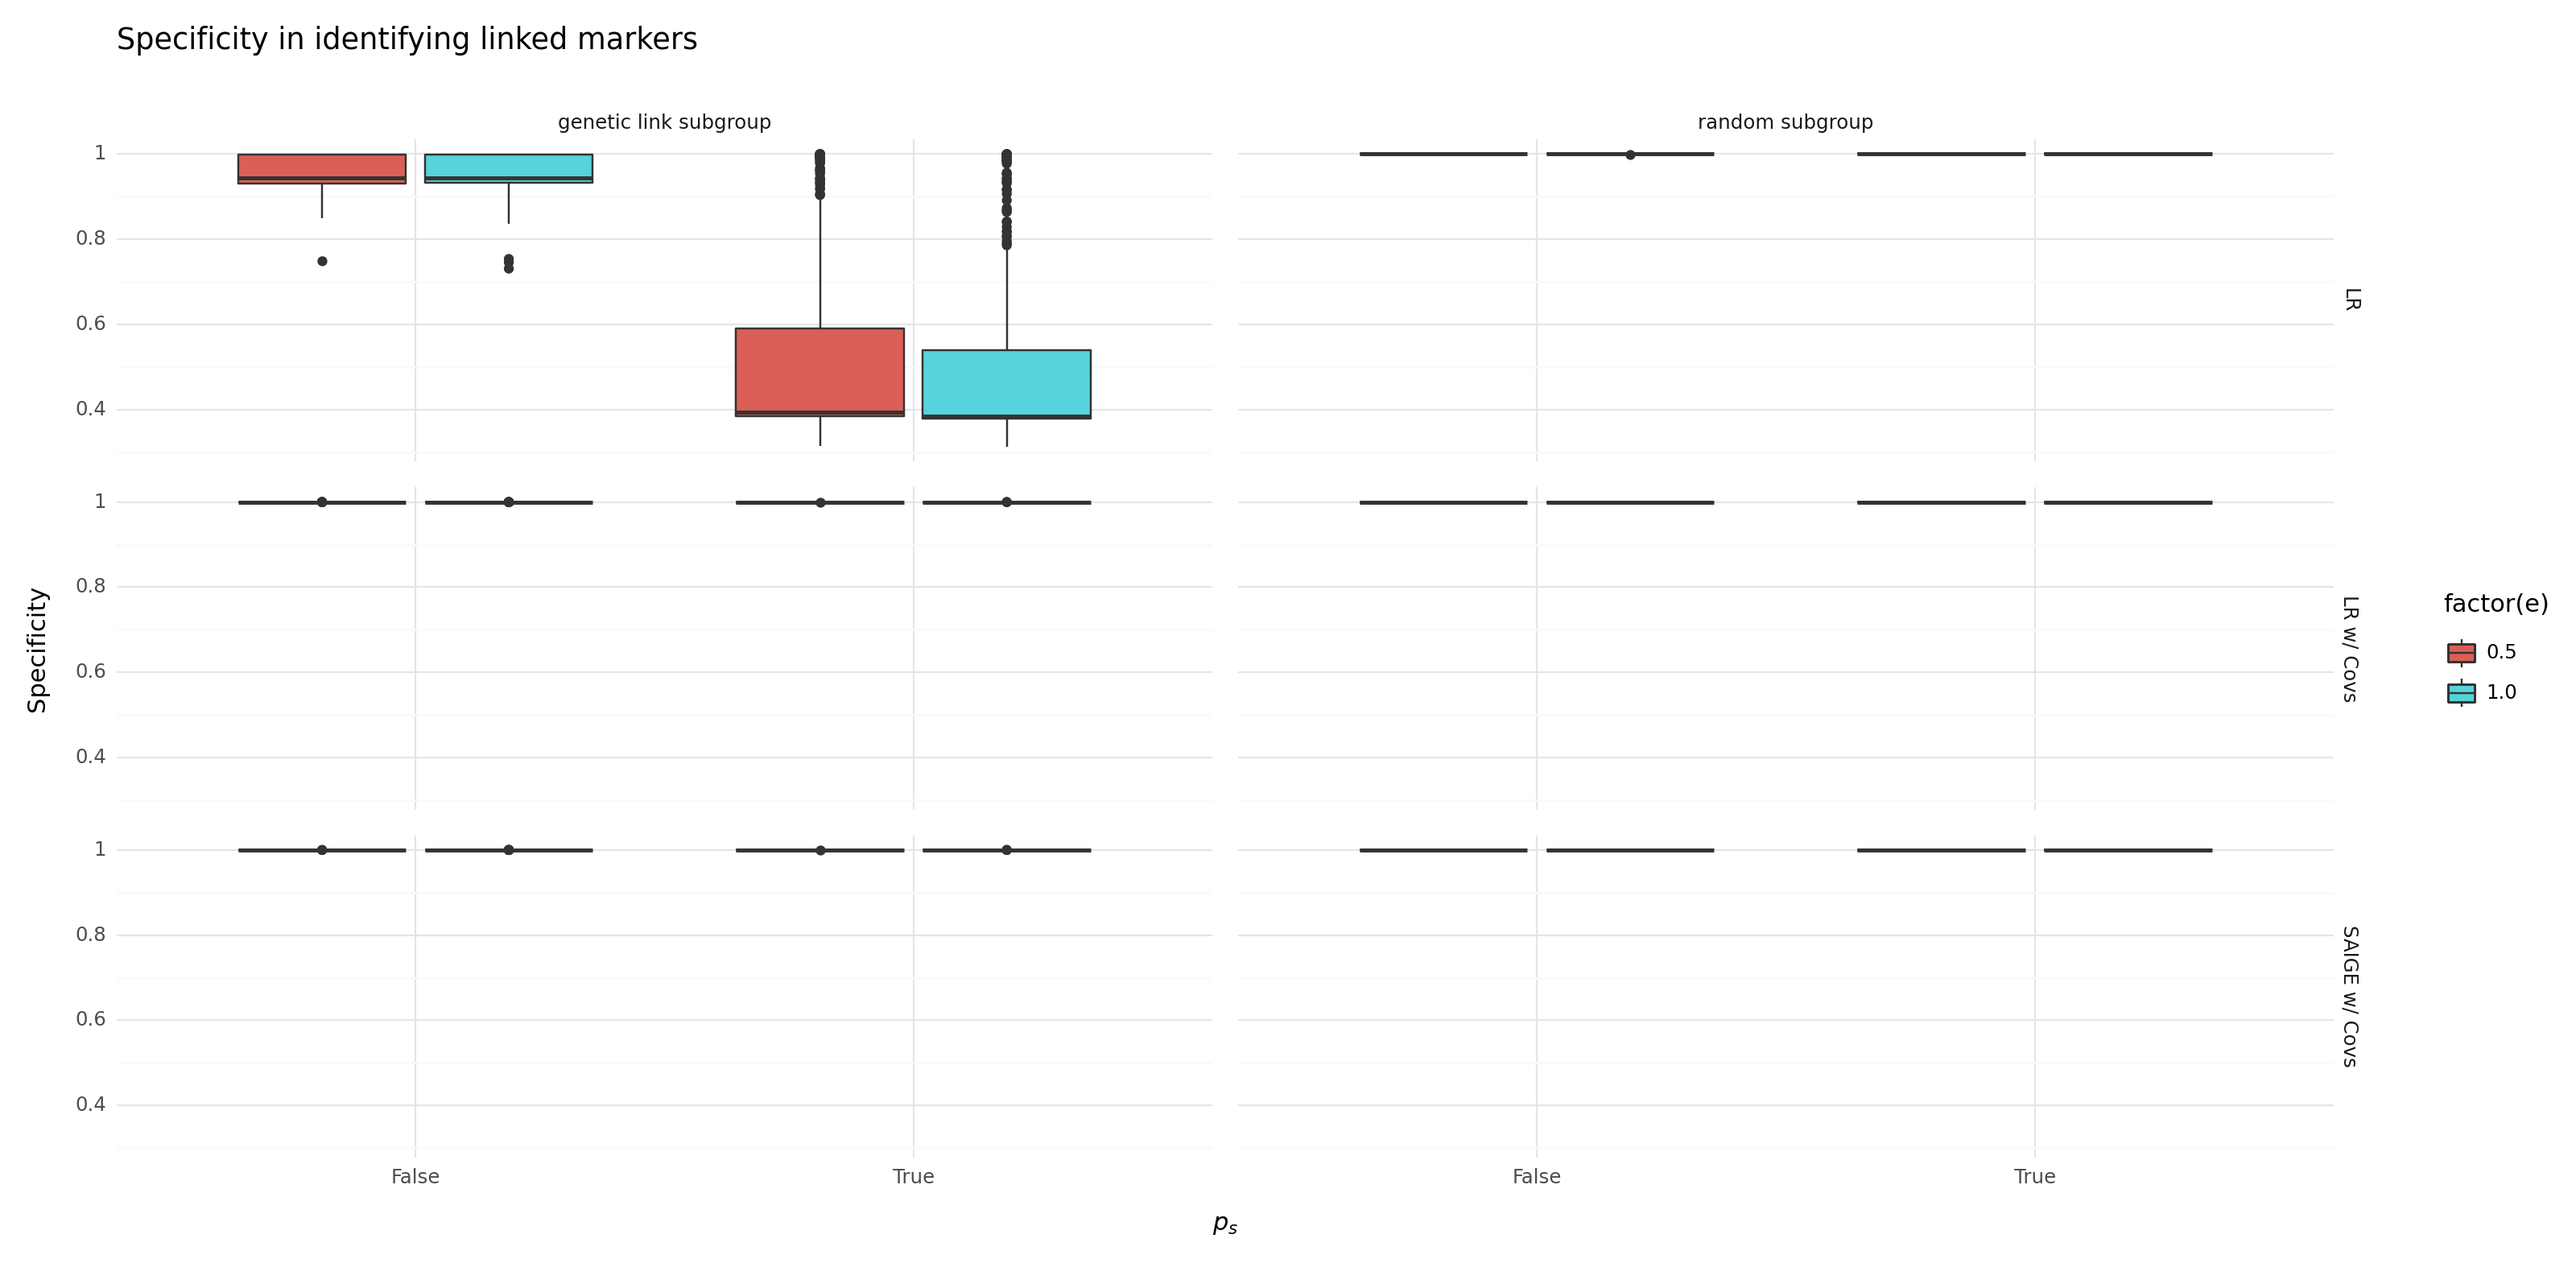

In [138]:
p = (ggplot(results_df, aes(x='ps', y='specificity',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(16,8))
    + facet_grid('assoc_test ~ subgroup_type')
    + labs(title=r'Specificity in identifying linked markers',y=r'Specificity',x=r'$p_s$')) 
print(p)

In [140]:
results_df['pred_pos'] = results_df['tp'] + results_df['fp'] 

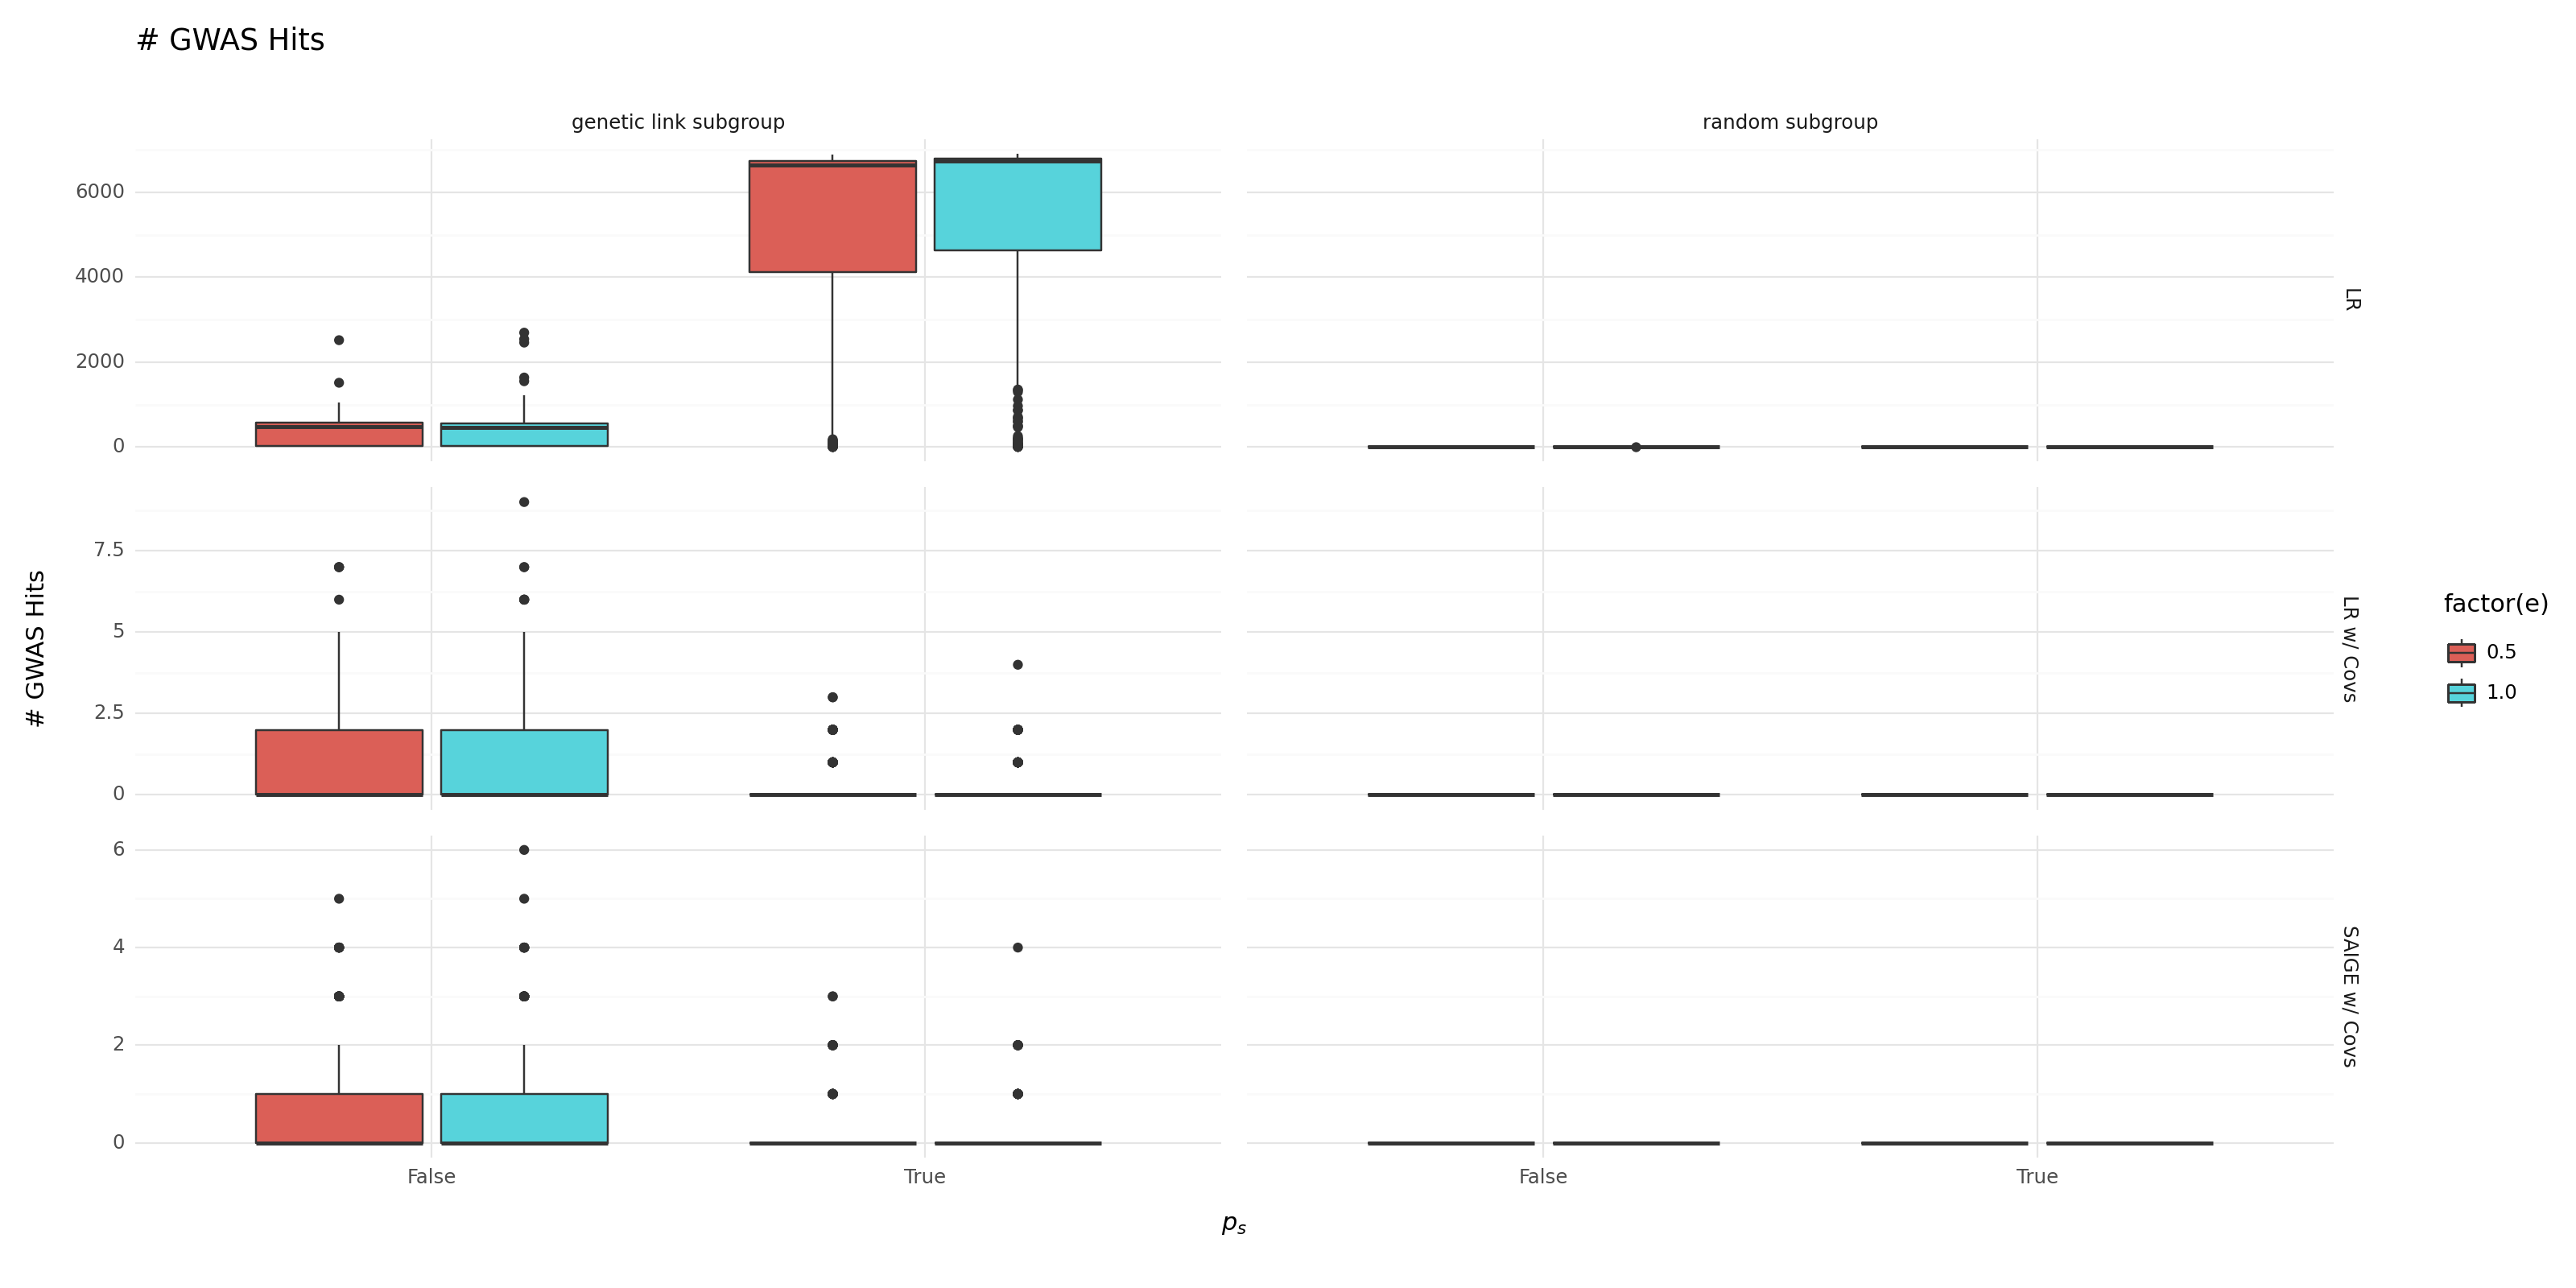

In [142]:
p = (ggplot(results_df, aes(x='ps', y='pred_pos',fill='factor(e)'))
    + geom_boxplot()
    + theme_minimal()
    + theme(figure_size=(16,8))
    + facet_grid('assoc_test ~ subgroup_type',scales='free_y')
    + labs(title=r'# GWAS Hits',y=r'# GWAS Hits',x=r'$p_s$')) 
print(p)

### Algorithm creation

In [4]:
root_dir = '/gpfs/commons/datasets/1000genomes'
import simulations.genomes1000_sim as sim_functions


In [5]:
# empirically, show monotone decrease of loss and stabilization over iterations
# show stability of parameter norms (U^t-U^(t-1))

# JointMF
import algorithms.JointMF as JointMF
import algorithms.JointMF_AAO as JointMF_AAO
import importlib
importlib.reload(JointMF)

writer = None

# read in simulated clinical data
ps = True
e = 1
init = 0
num_markers_assoc = 2000
output_suffix = f'ps_{ps}_e_{e}_init_{init}_markersassoc_{num_markers_assoc}'
C = np.load(f'{output_dir}/C_{output_suffix}.npy')
with open(f"{output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
    simulation_metadata = pickle.load(f)

# read in admixture fractions, sex and G
igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{output_dir}/G')
igsr_samples['Sex'] = igsr_samples['Sex'].map({'female': 0, 'male': 1})

admixture = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
fam_df = pd.read_csv(f'{output_dir}/G.fam',sep='\s+',header=None)
fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
admixture['IID'] = fam_df['IID'].values
Z_df = admixture.merge(igsr_samples[['IID','Sex']], on='IID',how='inner')
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy()

G = np.loadtxt(f'{output_dir}/G.raw',  usecols=range(6, 10000+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)


ML Flow practice

Force alternating optimization

In [6]:
def mats2vec(mats):
    """ Converts matrices back to vector form."""
    return np.concatenate([mat.flatten(order='F') for mat in mats])

def vec2mats(v, shapes): 
    """ Converts a vector into matrices based on given shapes.
    shapes is list of tuples defining shapes of each matrix to be formed
    """
    place_sum = 0
    mats = []
    for dim in shapes:
        size = dim[0]*dim[1]
        mats.append(v[place_sum:place_sum+size].reshape(dim[0], dim[1], order='F'))
        place_sum += size
    return mats

In [7]:
from scipy.special import gammaln

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [ ]:
def total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # define nec. elements
    G_hat = sigmoid(W@H_G.T + Z@U_G.T)
    # clipping for log purposes
    G_hat = np.clip(G_hat, 1e-7, 1 - 1e-7)
    C_hat = W@H_C.T + Z@U_C.T
    # clipping for log purposes
    C_hat = np.clip(C_hat, 1e-7, np.inf)

    E_g = np.ones(G.shape)

    # define loss
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    if kl_div_loss < 0:
        assert True == False, "KL divergence loss negative"
    if bce_loss < 0:
        assert True == False, "BCE loss negative"
    f = bce_loss + kl_div_loss + regularization 
    return f

# Per-block factories (compute precomputes once per inner solve)

def make_fg_W(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of W
    U1 = Z@U_G.T
    U2 = Z@U_C.T
    C_const = np.sum(gammaln(C + 1))
    E_g = np.ones(G.shape)
    E_c = np.ones(C.shape)
    reg = lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        W = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        # clipping for log purposes
        C_hat = np.clip(W@H_C.T + U2, 1e-7, np.inf)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const # log(C!) can help stabilize
        f = bce_loss + kl_div_loss + lambda_W/2* np.trace(W.T @ W) + reg 
        return f
    def jac(x):
        W = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        # clipping for log purposes
        C_hat = np.clip(W@H_C.T + U2, 1e-7, np.inf)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)
        C_tilde = np.divide(C,C_hat)

        GW = (np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat)@H_G 
                + (E_c - C_tilde)@H_C + lambda_W*W)
        return GW.flatten(order='F')
    return fun, jac

def make_fg_HG(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of H_G
    U1 = Z@U_G.T
    C_hat = np.clip(W@H_C.T + Z@U_C.T, 1e-7, np.inf)
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    E_g = np.ones(G.shape)
    reg = lambda_W/2* np.trace(W.T @ W) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        H_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        f = bce_loss + kl_div_loss + reg +  lambda_H_G/2* np.trace(H_G.T @ H_G)
        return f
    def jac(x):
        H_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(W@H_G.T + U1), 1e-7, 1 - 1e-7)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)

        GH_G = (W.T@np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat)).T + lambda_H_G*H_G
        return GH_G.flatten(order='F')
    return fun, jac

def make_fg_HC(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of H_C
    U1 = Z@U_C.T
    E_c = np.ones(C.shape)
    C_const = np.sum(gammaln(C + 1))
    G_hat = np.clip(sigmoid(W@H_G.T + Z@U_G.T), 1e-7, 1 - 1e-7)
    E_g = np.ones(G.shape)
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    reg = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G)
    def fun(x):
        H_C = x.reshape(shape, order='F')
        C_hat = np.clip(W@H_C.T + U1, 1e-7, np.inf)
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const # log(C!) can help stabilize
        f = bce_loss + kl_div_loss + reg +  lambda_H_C/2* np.trace(H_C.T @ H_C)
        return f
    def jac(x):
        H_C = x.reshape(shape, order='F')
        C_hat = np.clip(W@H_C.T + U1, 1e-7, np.inf)

        C_tilde = np.divide(C,C_hat)

        GH_C = (W.T@(E_c - C_tilde)).T + lambda_H_C*H_C
        return GH_C.flatten(order='F')
    return fun, jac

def make_fg_UG(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of U_G
    U1 = W@H_G.T
    C_hat = np.clip(W@H_C.T + Z@U_C.T, 1e-7, np.inf)
    kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat + gammaln(C + 1)) # log(C!) can help stabilize
    E_g = np.ones(G.shape)
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        U_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(U1 + Z@U_G.T), 1e-7, 1 - 1e-7)
        bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
        f = bce_loss + kl_div_loss + regularization
        return f
    def jac(x):
        U_G = x.reshape(shape, order='F')
        # clipping for log purposes
        G_hat = np.clip(sigmoid(U1 + Z@U_G.T), 1e-7, 1 - 1e-7)

        G_tilde = np.divide(G,G_hat)
        G_bar = np.divide(E_g-G,E_g-G_hat)

        GU_G = (Z.T@(np.multiply(np.multiply(-G_tilde + G_bar,G_hat),E_g - G_hat))).T
        return GU_G.flatten(order='F')
    return fun, jac

def make_fg_UC(shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C):
    # Precompute terms independent of U_C
    U1 = W@H_C.T
    E_c = np.ones(C.shape)
    C_const = np.sum(gammaln(C + 1))
    G_hat = np.clip(sigmoid(W@H_G.T + Z@U_G.T), 1e-7, 1 - 1e-7)
    E_g = np.ones(G.shape)
    bce_loss = np.sum(-np.multiply(G,np.log(G_hat)) - np.multiply(E_g-G,np.log(E_g-G_hat)))
    regularization = lambda_W/2* np.trace(W.T @ W) +  lambda_H_G/2* np.trace(H_G.T @ H_G) +  lambda_H_C/2* np.trace(H_C.T @ H_C)
    def fun(x):
        U_C = x.reshape(shape, order='F')
        C_hat = np.clip(U1 + Z@U_C.T, 1e-7, np.inf)
        kl_div_loss = np.sum(-np.multiply(C,np.log(C_hat)) + C_hat) + C_const
        f = bce_loss + kl_div_loss + regularization
        return f
    def jac(x):
        U_C = x.reshape(shape, order='F')
        C_hat = np.clip(U1 + Z@U_C.T, 1e-7, np.inf)

        C_tilde = np.divide(C,C_hat)

        GU_C = (Z.T@(E_c - C_tilde)).T
        return GU_C.flatten(order='F')
    return fun, jac

In [ ]:
import numpy as np
from scipy.optimize import minimize

def alternating_opt(
    G,C,Z,              # true matrices
    W, H_G, H_C, U_G, U_C,  # initializations
    lambda_W, lambda_H_G, lambda_H_C,                   # regularization parameters
    method,                 # method and options for scipy minimize
    options,
    max_outer=30,
    tol=1e-4,
    nonneg=True             # set per-block L-BFGS-B bounds to [0, +inf)
):
    def one_block_update(name, X, method, options):
        x0 = X.flatten(order='F') 
        bnds = [(0, np.inf)] * x0.size if nonneg else None

        if name == "W":
            fun, jac = make_fg_W(W.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "H_G":
            fun, jac = make_fg_HG(H_G.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "H_C":
            fun, jac = make_fg_HC(H_C.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "U_G":
            fun, jac = make_fg_UG(U_G.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        elif name == "U_C":
            fun, jac = make_fg_UC(U_C.shape, G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        else:
            raise ValueError(f"Unknown block {name}")

        res = minimize(fun, x0, method=method, jac=jac, bounds=bnds, options=options)
        return res.x.reshape(X.shape, order='F')

    # initial objective
    f_prev = total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)

    for _ in range(max_outer):
        W   = one_block_update("W",   W, method, options)
        H_G = one_block_update("H_G", H_G, method, options)
        H_C = one_block_update("H_C", H_C, method, options)
        U_G = one_block_update("U_G", U_G, method, options)
        U_C = one_block_update("U_C", U_C, method, options)

        f_cur = total_loss(G, C, Z, W, H_G, H_C, U_G, U_C, lambda_W, lambda_H_G, lambda_H_C)
        if (f_prev - f_cur) / max(1.0, abs(f_prev)) < tol:
            break
        f_prev = f_cur

    return W, H_G, H_C, U_G, U_C


with covariates

In [75]:
loss_history = {'hi':[1,2,3], 'yes':[4,5,6]}
assert len({len(v) for v in loss_history.values()}) == 1, f"Lengths differ: { {k: len(v) for k, v in loss_history.items()} }"
num_epochs = [len(v) for v in loss_history.values()][0]

In [76]:
num_epochs

3

In [9]:
rank = 4
col = 100 
lambda_W, lambda_H_G, lambda_H_C = (0,0,0)
W = np.random.random((G[:,:col].shape[0], rank))*1e-2+1e-6 
H_G = np.random.random((G[:,:col].shape[1], rank))*1e-2+1e-6
H_C = np.random.random((C.shape[1], rank))*1e-2+1e-6
U_G = np.random.random((G[:,:col].shape[1], Z.shape[1]))*1e-2+1e-6
U_C = np.random.random((C.shape[1], Z.shape[1]))*1e-2+1e-6
factor_matrices, loss_function = JointMF.alternating_opt(G[:,:col],C,Z,W, H_G, H_C, U_G, U_C,lambda_W, lambda_H_G, lambda_H_C, 
    method='L-BFGS-B',options={'maxcor':10, 'maxiter':10, 'gtol':1e-5, 'maxls':5, 'ftol':1e-6},tol=1e-4,nonneg=True)

In [57]:
S = np.empty((4, 4), dtype=float)
def jaccard_index_numpy(a, b):
    a, b = np.array(a), np.array(b)
    intersection = np.sum((a & b) > 0)
    union = np.sum((a | b) > 0)
    return intersection / union if union != 0 else 0.0

for i in range(4):
    for j in range(4):
        p = W[:, j]
        yhat = (p >= np.quantile(p, 0.5)).astype(int)
        S[i, j] = jaccard_index_numpy(W_true[:, i], yhat)
S

array([[0.16744186, 0.17525084, 0.15137615, 0.16357616],
       [0.16778075, 0.17012726, 0.16002656, 0.1592568 ],
       [0.07317073, 0.0739645 , 0.077951  , 0.07079646],
       [0.0668626 , 0.07715134, 0.06843267, 0.07079646]])

In [33]:
S = np.empty((4, 4), dtype=float)

for i in range(4):
    for j in range(4):
        S[i, j] = pair_similarity_ap(W_true[:, i], W[:, j])
S

array([[0.20089153, 0.20565546, 0.1942942 , 0.20402883],
       [0.19513484, 0.20193228, 0.19554617, 0.19999571],
       [0.08189893, 0.08371522, 0.07997323, 0.07657325],
       [0.07534978, 0.08926822, 0.07242574, 0.07809682]])

In [ ]:
compute_sim_metrics(W_true,W)

In [14]:
W_true = simulation_metadata['phenotypic_subgroups'].pivot(index='IID',columns='phenotypic_subgroup',values='subgroup').to_numpy().astype(int)

In [24]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, f1_score, precision_score, recall_score
)
from scipy.optimize import linear_sum_assignment


def pair_similarity_ap(y_true_col, y_pred_col):
    """Average Precision; returns -inf if y_true is all one class (undefined AP)."""
    return average_precision_score(y_true_col, y_pred_col)

def compute_sim_metrics(W_true,W):
    # 1) Build similarity matrix S 4x4
    S = np.empty((4, 4), dtype=float)

    for i in range(4):
        for j in range(4):
            S[i, j] = pair_similarity_ap(W_true[:, i], W[:, j])
    # assign match up between row and col
    row_ind, col_ind = linear_sum_assignment(-S)

    # return results df
    results = []
    for i_true, j_pred in zip(row_ind, col_ind):
        y = W_true[:, i_true]
        p = W[:, j_pred]
        p_probs = p / np.sum(p)

        # Probabilistic metrics (robust to class imbalance)
        # Guard AUROC for degenerate y:
        auroc = roc_auc_score(y, p_probs)
        auprc = average_precision_score(y, p_probs) if y.min() != y.max() else np.nan
        brier = brier_score_loss(y, p_probs)

        # (If you want a prevalence- or cost-aware threshold, swap this rule.)
        precs, recs, thresh = precision_recall_curve(y, p_probs)


        yhat = (p_probs >= 0.5).astype(int)
        f1  = f1_score(y, yhat) if y.min() != y.max() else np.nan
        prec = precision_score(y, yhat, zero_division=0)
        rec  = recall_score(y, yhat, zero_division=0)

        results.append({
            "true_subgroup_idx": int(i_true),
            "pred_cluster_idx": int(j_pred),
            "similarity_AP": S[i_true, j_pred],
            "AUROC": auroc,
            "AUPRC": auprc,
            "Brier": brier,
            "F1": f1,
            "Precision": prec,
            "Recall": rec,
        })

    results_df = pd.DataFrame(results)
    return results_df


try without Z

In [27]:
W = np.random.random((G.shape[0], rank))*1e-2+1e-6 
H_G = np.random.random((G.shape[1], rank))*1e-2+1e-6
H_C = np.random.random((C.shape[1], rank))*1e-2+1e-6
U_G = np.random.random((G.shape[1], Z.shape[1]))*1e-2+1e-6
U_C = np.random.random((C.shape[1], Z.shape[1]))*1e-2+1e-6
W, H_G, H_C, U_G, U_C = alternating_opt(G,C,np.zeros((Z.shape[0],Z.shape[1])),W, H_G, H_C, U_G, U_C,lambda_W, lambda_H_G, lambda_H_C, 
    method='L-BFGS-B',options={'maxcor':10, 'maxiter':10, 'gtol':1e-5, 'maxls':20, 'ftol':1e-6},tol=1e-4,nonneg=True)


17197197.400059305
16885692.4893156
16819934.127122454
16779093.881044537
16759399.874805398
16749621.017030803
16747025.953120593
16746268.570220577


In [28]:
compute_sim_metrics(W_true,W)

,true_subgroup_idx,pred_cluster_idx,similarity_AP,AUROC,AUPRC,Brier,F1,Precision,Recall
0,0,0,0.351563,0.711274,0.351563,0.201385,0.0,0.0,0.0
1,1,2,0.192982,0.353164,0.192982,0.197668,0.0,0.0,0.0
2,2,3,0.084919,0.511816,0.084919,0.079806,0.0,0.0,0.0
3,3,1,0.081999,0.492331,0.081999,0.079811,0.0,0.0,0.0


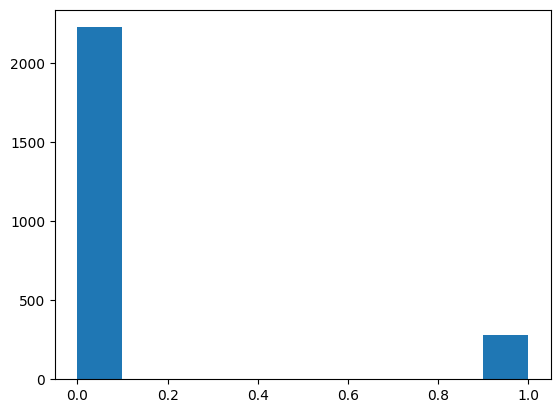

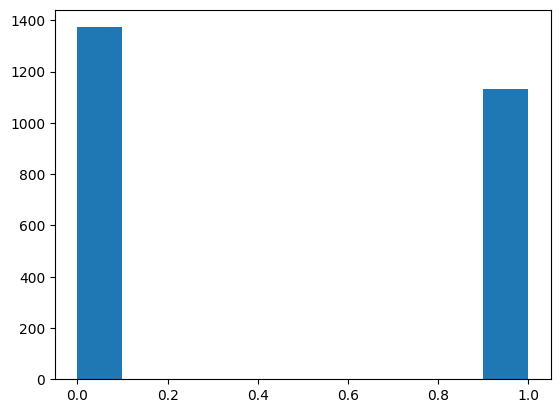

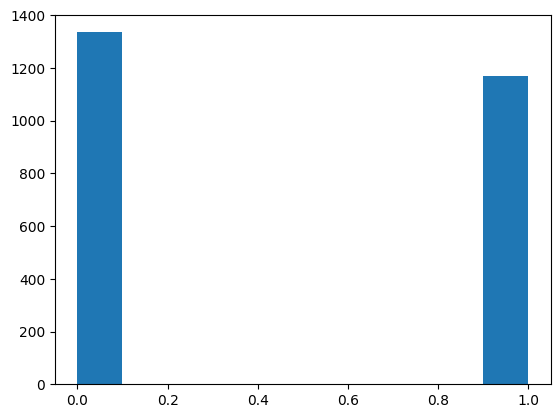

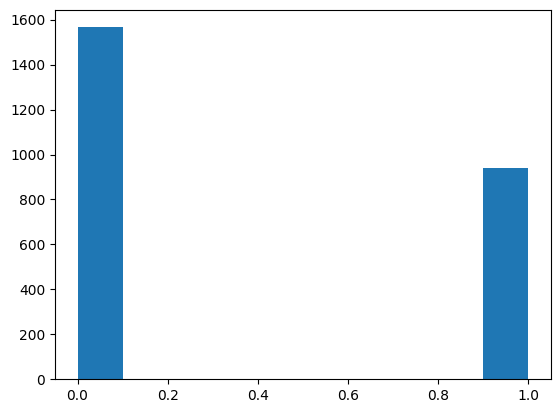

<Figure size 640x480 with 0 Axes>

In [47]:
import matplotlib.pyplot as plt
for i in range(4):
    plt.hist(G[:,i])
    plt.show()
    plt.clf()

without covariates

In [43]:
assert all(np.isclose(W,W1).ravel())
assert all(np.isclose(H_G,H_G1).ravel())
assert all(np.isclose(H_C,H_C1,atol=1e-04).ravel(),)
assert all(np.isclose(U_G,U_G1).ravel())
assert all(np.isclose(U_C,U_C1).ravel())